In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from datasets import load_dataset
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import wandb


# Load the STL-10 dataset from Huggingface
dataset = load_dataset("Chiranjeev007/STL-10_Subset")

# Extract train, validation, and test sets
train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 5000
Validation samples: 500
Test samples: 1000


In [6]:
class STL10Dataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        label = self.dataset[idx]['label']
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label

# Define transforms
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets and dataloaders
train_loader = DataLoader(STL10Dataset(train_dataset, transform), batch_size=32, shuffle=True)
val_loader   = DataLoader(STL10Dataset(val_dataset, transform),   batch_size=32, shuffle=False)
test_loader  = DataLoader(STL10Dataset(test_dataset, transform),  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 157, Val batches: 16, Test batches: 32


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-18 and modify the final layer for 10 classes
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Initialize WandB
wandb.init(project="B22BB041CSL7120-Minor-Q2", name="resnet18-training")

# Re-train the model and log metrics to WandB
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss_avg = train_loss / len(train_loader.dataset)
    train_acc_avg  = train_correct / len(train_loader.dataset)
    val_loss_avg   = val_loss / len(val_loader.dataset)
    val_acc_avg    = val_correct / len(val_loader.dataset)

    # Log metrics to WandB
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss_avg,
        "train_accuracy": train_acc_avg,
        "val_loss": val_loss_avg,
        "val_accuracy": val_acc_avg
    })

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc_avg:.4f} | "
          f"Val Loss: {val_loss_avg:.4f}, Val Acc: {val_acc_avg:.4f}")

wandb.finish()

Epoch [1/10] Train Loss: 0.1197, Train Acc: 0.9626 | Val Loss: 1.1293, Val Acc: 0.7320
Epoch [2/10] Train Loss: 0.1034, Train Acc: 0.9694 | Val Loss: 1.0990, Val Acc: 0.7600
Epoch [3/10] Train Loss: 0.0820, Train Acc: 0.9746 | Val Loss: 1.2433, Val Acc: 0.7240
Epoch [4/10] Train Loss: 0.0666, Train Acc: 0.9798 | Val Loss: 1.2052, Val Acc: 0.7360
Epoch [5/10] Train Loss: 0.0459, Train Acc: 0.9850 | Val Loss: 1.2884, Val Acc: 0.7300
Epoch [6/10] Train Loss: 0.0619, Train Acc: 0.9804 | Val Loss: 1.4816, Val Acc: 0.7000
Epoch [7/10] Train Loss: 0.0872, Train Acc: 0.9728 | Val Loss: 1.2810, Val Acc: 0.7340
Epoch [8/10] Train Loss: 0.0712, Train Acc: 0.9778 | Val Loss: 1.3312, Val Acc: 0.7200
Epoch [9/10] Train Loss: 0.0626, Train Acc: 0.9810 | Val Loss: 1.2480, Val Acc: 0.7380
Epoch [10/10] Train Loss: 0.0274, Train Acc: 0.9906 | Val Loss: 1.0709, Val Acc: 0.7680


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▇▅▄▅▆█
train_loss,█▇▅▄▂▄▆▄▄▁
val_accuracy,▄▇▃▅▄▁▅▃▅█
val_loss,▂▁▄▃▅█▅▅▄▁
epoch,10
train_accuracy,0.9906
train_loss,0.02736
val_accuracy,0.768
val_loss,1.07085


In [13]:
torch.save(model.state_dict(), "resnet18_stl10.pth")
print("Model saved to resnet18_stl10.pth")

Model saved to resnet18_stl10.pth


In [15]:
!pip install huggingface_hub

In [27]:
!hf auth login

User is already logged in.


In [29]:
from huggingface_hub import HfApi

api = HfApi()

# Replace 'your-username/your-repo-name' with your actual Hugging Face username and desired repository name
repo_id = "Sids27/resnet18-stl10"

# Create the repository if it doesn't exist (optional, but good practice)
api.create_repo(repo_id=repo_id, exist_ok=True, private=False)

# Upload the saved model file
api.upload_file(
    path_or_fileobj="resnet18_stl10.pth",
    path_in_repo="resnet18_stl10.pth",
    repo_id=repo_id,
    repo_type="model",
)

print(f"Model resnet18_stl10.pth uploaded to Hugging Face Hub at {repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  resnet18_stl10.pth          :   1%|1         |  560kB / 44.8MB            

Model resnet18_stl10.pth uploaded to Hugging Face Hub at Sids27/resnet18-stl10


In [31]:
from huggingface_hub import hf_hub_download

# Define the repository ID where the model is stored
repo_id = "Sids27/resnet18-stl10"

# Define the filename of the model checkpoint
filename = "resnet18_stl10.pth"

# Download the model checkpoint from Hugging Face Hub
model_path = hf_hub_download(repo_id=repo_id, filename=filename)

# Load the pretrained ResNet-18 model architecture
loaded_model = models.resnet18(pretrained=False)

# Modify the final layer for 10 classes
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, 10)

loaded_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# Set the model to evaluation mode
loaded_model.eval()

print(f"Model loaded successfully from {model_path}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully from /root/.cache/huggingface/hub/models--Sids27--resnet18-stl10/snapshots/3e05ec8f4cb13c04036c062a4431267605a77389/resnet18_stl10.pth


In [32]:
from sklearn.metrics import confusion_matrix

# Initialize WandB for the confusion matrix logging
wandb.init(project="B22BB041CSL7120-Minor-Q2", name="confusion-matrix")

In [34]:
all_preds = []
all_labels = []

loaded_model.to(device)

# Iterate over the test set
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Log the confusion matrix to WandB
class_names = [str(i) for i in range(10)]

wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
    probs=None,
    y_true=all_labels,
    preds=all_preds,
    class_names=class_names
)})

print("Confusion matrix logged to WandB.")

wandb.finish()

Confusion matrix logged to WandB.


/tmp/ipython-input-2751975911.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Accuracy', data=accuracy_df, palette='viridis')


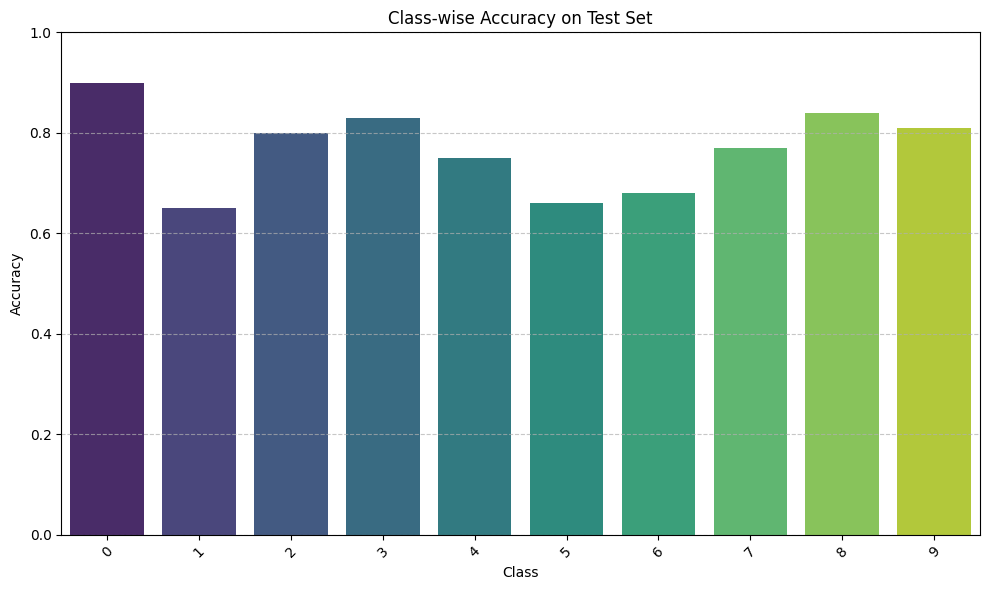

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Calculate class-wise accuracy from the confusion matrix
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Create a DataFrame for easier plotting with seaborn
accuracy_df = pd.DataFrame({
    'Class': class_names,
    'Accuracy': class_accuracies
})

# Plot the class-wise accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Class-wise Accuracy on Test Set')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
import random

# Initialize WandB for logging samples
wandb.init(project="B22BB041CSL7120-Minor-Q2", name="test-samples-visualization")

all_samples_info = []

# Define denormalization parameters based on the original transform
mean_vals = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_vals = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
to_pil = transforms.ToPILImage()

with torch.no_grad():
    for images, labels in test_loader:
        # Move images and labels to the device for prediction
        images_on_device, labels_on_device = images.to(device), labels.to(device)

        outputs = loaded_model(images_on_device)
        _, predicted = torch.max(outputs.data, 1)

        for i in range(images.size(0)):
            img_tensor = images[i].cpu() # Get the transformed image tensor back to CPU

            # Denormalize the image tensor for proper display
            img_denorm = img_tensor * std_vals + mean_vals
            img_denorm = torch.clamp(img_denorm, 0, 1) # Clip values to [0, 1]

            img_pil = to_pil(img_denorm) # Convert to PIL Image

            actual_label = labels[i].item()
            predicted_label = predicted[i].item()
            is_correct = (actual_label == predicted_label)

            all_samples_info.append({
                "image": img_pil,
                "actual": actual_label,
                "predicted": predicted_label,
                "is_correct": is_correct
            })

# Separate correct and incorrect samples
correct_samples = [s for s in all_samples_info if s["is_correct"]]
incorrect_samples = [s for s in all_samples_info if not s["is_correct"]]

# Select 10 random correct and 10 random incorrect samples
num_to_sample = 10
selected_correct = random.sample(correct_samples, min(num_to_sample, len(correct_samples)))
selected_incorrect = random.sample(incorrect_samples, min(num_to_sample, len(incorrect_samples)))

# Prepare images for WandB
wandb_images = []

for sample in selected_correct:
    caption = f"Actual: {class_names[sample['actual']]}, Predicted: {class_names[sample['predicted']]} (Correct)"
    wandb_images.append(wandb.Image(sample["image"], caption=caption))

for sample in selected_incorrect:
    caption = f"Actual: {class_names[sample['actual']]}, Predicted: {class_names[sample['predicted']]} (Incorrect)"
    wandb_images.append(wandb.Image(sample["image"], caption=caption))

# Log the images to WandB
wandb.log({"Test Samples (Correct/Incorrect)": wandb_images})

print(f"Logged {len(selected_correct)} correct and {len(selected_incorrect)} incorrect samples to WandB.")
wandb.finish()

Logged 10 correct and 10 incorrect samples to WandB.


In [40]:
print("Class-wise Accuracies:")
for i, acc in enumerate(class_accuracies):
    print(f"Class {class_names[i]}: {acc:.2f}")

Class-wise Accuracies:
Class 0: 0.90
Class 1: 0.65
Class 2: 0.80
Class 3: 0.83
Class 4: 0.75
Class 5: 0.66
Class 6: 0.68
Class 7: 0.77
Class 8: 0.84
Class 9: 0.81
